In [1]:
print("hello world")

hello world


In [2]:
print("execute")

execute


In [1]:
from pathlib import Path

train_dir = Path("../raw_data/FruitinAmazon/train")

print("Path exists:", train_dir.exists())
print("Is directory:", train_dir.is_dir())
print("Absolute path:", train_dir.resolve())

Path exists: True
Is directory: True
Absolute path: D:\2. deep learning code\pytorch_deeplearning_research_template\raw_data\FruitinAmazon\train


# Check Class Folders

In [2]:
classes = [d.name for d in train_dir.iterdir() if d.is_dir()]

print("Classes:")
print(classes)
print(f"\nNumber of classes: {len(classes)}")

Classes:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Number of classes: 6


# Count images per class

In [3]:
for cls in classes:
    class_dir = train_dir / cls

    images = list(class_dir.glob("*"))

    print(f"{cls}: {len(images)} images")

acai: 15 images
cupuacu: 15 images
graviola: 15 images
guarana: 15 images
pupunha: 15 images
tucuma: 15 images


In [4]:
import sys
from pathlib import Path

# go UP from notebooks → project root
PROJECT_ROOT = Path().resolve().parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Added:", PROJECT_ROOT)

Added: D:\2. deep learning code\pytorch_deeplearning_research_template


In [5]:
import sys
print(sys.path[:5])

['D:\\2. deep learning code\\pytorch_deeplearning_research_template', 'c:\\Users\\LENOVO\\miniconda3\\envs\\dl-workshop\\python310.zip', 'c:\\Users\\LENOVO\\miniconda3\\envs\\dl-workshop\\DLLs', 'c:\\Users\\LENOVO\\miniconda3\\envs\\dl-workshop\\lib', 'c:\\Users\\LENOVO\\miniconda3\\envs\\dl-workshop']


In [6]:
from src.data.dataset import ImageClassificationDataset

print("IMPORT SUCCESS")

IMPORT SUCCESS


In [7]:
# Test your Dataset class
from src.data.dataset import ImageClassificationDataset

dataset = ImageClassificationDataset(
    root_dir=str(train_dir)
)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Dataset size: 90
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Class mapping: {'acai': 0, 'cupuacu': 1, 'graviola': 2, 'guarana': 3, 'pupunha': 4, 'tucuma': 5}


In [8]:
# inspect sample
image, label = dataset[0]

print(type(image))
print(label)

<class 'PIL.Image.Image'>
0


In [9]:
# Test your DataLoader
from src.data.dataloader import get_dataloader

loader = get_dataloader(
    root_directory=str(train_dir),
    batch_size=4,
    shuffle=True
)

print("Number of batches:", len(loader))

Number of batches: 23


In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()   
])

In [11]:
dataset = ImageClassificationDataset(
    root_dir=str(train_dir),
    transform=transform
)

In [12]:
# inspect sample
image, label = dataset[0]

print(type(image))
print(label)

<class 'torch.Tensor'>
0


In [13]:
# Inspect one batch
for images, labels in loader:
    print(images.shape)
    print(labels)
    break

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\LENOVO\miniconda3\envs\dl-workshop\lib\site-packages\torch\utils\data\_utils\worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\LENOVO\miniconda3\envs\dl-workshop\lib\site-packages\torch\utils\data\_utils\fetch.py", line 57, in fetch
    return self.collate_fn(data)
  File "c:\Users\LENOVO\miniconda3\envs\dl-workshop\lib\site-packages\torch\utils\data\_utils\collate.py", line 401, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "c:\Users\LENOVO\miniconda3\envs\dl-workshop\lib\site-packages\torch\utils\data\_utils\collate.py", line 214, in collate
    return [
  File "c:\Users\LENOVO\miniconda3\envs\dl-workshop\lib\site-packages\torch\utils\data\_utils\collate.py", line 215, in <listcomp>
    collate(samples, collate_fn_map=collate_fn_map)
  File "c:\User

In [14]:
from src.data.dataset import ImageClassificationDataset
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = ImageClassificationDataset(
    root_dir=r"raw_data\FruitinAmazon\train",
    transform=transform
)

print("SAMPLE TYPE:", type(dataset[0][0]))  # MUST be Tensor

loader = DataLoader(dataset, batch_size=4)

for x, y in loader:
    print(type(x))
    print(x.shape)
    break

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'raw_data\\FruitinAmazon\\train'

In [15]:
from src.data.dataset import ImageClassificationDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = ImageClassificationDataset(
    root_dir=str(train_dir),
    transform=transform
)

print("Dataset size:", len(dataset))

Dataset size: 90


In [16]:
img, label = dataset[0]

print(type(img))   # MUST be torch.Tensor
print(img.shape)   # MUST be (C, H, W)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 128, 128])
0


In [17]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

for images, labels in loader:
    print(type(images))
    print(images.shape)
    print(labels)
    break

<class 'torch.Tensor'>
torch.Size([4, 3, 128, 128])
tensor([2, 3, 0, 2])


In [19]:
import matplotlib.pyplot as plt

# get one sample from dataset
image, label = dataset[0]

print("Image type:", type(image))
print("Label:", label)
print("Image shape:", image.shape)

Image type: <class 'torch.Tensor'>
Label: 0
Image shape: torch.Size([3, 128, 128])


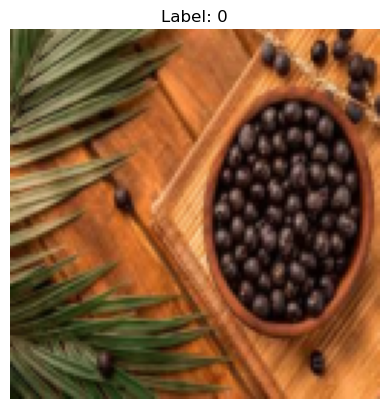

In [20]:
import matplotlib.pyplot as plt

image, label = dataset[0]

# convert CHW → HWC
img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

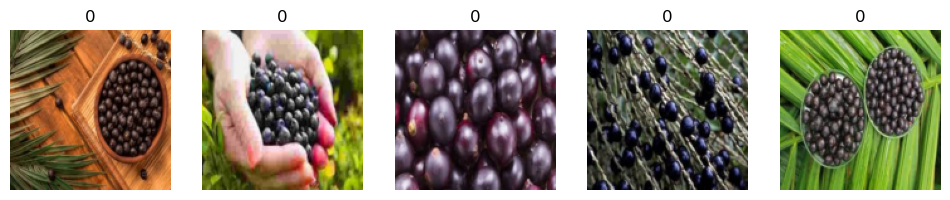

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = dataset[i]
    img = image.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

# Sample image (one per class)

In [ ]:
# Build Class-wise index mapping
class_indices = {cls: [] for cls in dataset.classes}

for idx in range(len(dataset)):
    _, label = dataset[idx]
    class_name = dataset.classes[label]
    class_indices[class_name].append(idx)
# pick one sample per class
selected_indices = []

for cls in dataset.classes:
    selected_indices.append(class_indices[cls][0])  # first image per class
# Visualize one sample per class
fig, axes = plt.subplots(1, len(selected_indices), figsize=(15, 3))

for i, idx in enumerate(selected_indices):
    image, label = dataset[idx]
    img = image.permute(1, 2, 0)

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label])
    axes[i].axis("off")

plt.show()